In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import scipy.stats as stats   # might be unused but harmless for plots
import random
import glob
import os
import re

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

sns.set_theme(style="whitegrid")
seed = 42
np.random.seed(seed)
random.seed(seed)


In [2]:
# Map raw method names from the battery evaluation .pkl files
# to canonical short method IDs used in plots.

label_map_battery = {
    # DiRoCA radii
    'DiRoCA (epsilon_0.558_delta_0.417)': 'DiRoCA_star',   # theoretical (ε*, δ*)
    'DiRoCA (epsilon_1.0_delta_1.0)':     'DIROCA_1',
    'DiRoCA (epsilon_2.0_delta_2.0)':     'DIROCA_2',
    'DiRoCA (epsilon_4.0_delta_4.0)':     'DIROCA_4',
    'DiRoCA (epsilon_8.0_delta_8.0)':     'DIROCA_8',
    # we *do* have epsilon_0.5_delta_0.5 in the results, but we don't plot it
    # in the main figure (to stay consistent with SLC/LiLUCAS layout).
    # If you want it, just add:
    # 'DiRoCA (epsilon_0.5_delta_0.5)': 'DIROCA_0_5',

    # Baselines
    'Gradca':                 'GradCA',
    'Baryca':                 'BARYCA',
    'Abs-LiNGAM (Perfect)':   'Abslin_p',
    'Abs-LiNGAM (Noisy)':     'Abslin_n',
}

# Pretty LaTeX-style labels for the canonical method IDs
print_label_map = {
    'DiRoCA_star':  r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$',
    'DIROCA_1':     r'DiRoCA$_{1,1}$',
    'DIROCA_2':     r'DiRoCA$_{2,2}$',
    'DIROCA_4':     r'DiRoCA$_{4,4}$',
    'DIROCA_8':     r'DiRoCA$_{8,8}$',
    'GradCA':       r'GRAD$_{(\tau, \omega)}$',
    'BARYCA':       r'BARY$_{(\tau, \omega)}$',
    'Abslin_p':     r'AbsLin$_{\text{p}}$',
    'Abslin_n':     r'AbsLin$_{\text{n}}$'
}


### Fix σ, vary α

Loaded evaluation file for gaussian: battery_eval_additive_gaussian_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_20251121_150415.pkl
Loaded evaluation file for student-t: battery_eval_additive_student-t_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_20251121_151020.pkl
Loaded evaluation file for exponential: battery_eval_additive_exponential_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_20251121_151535.pkl


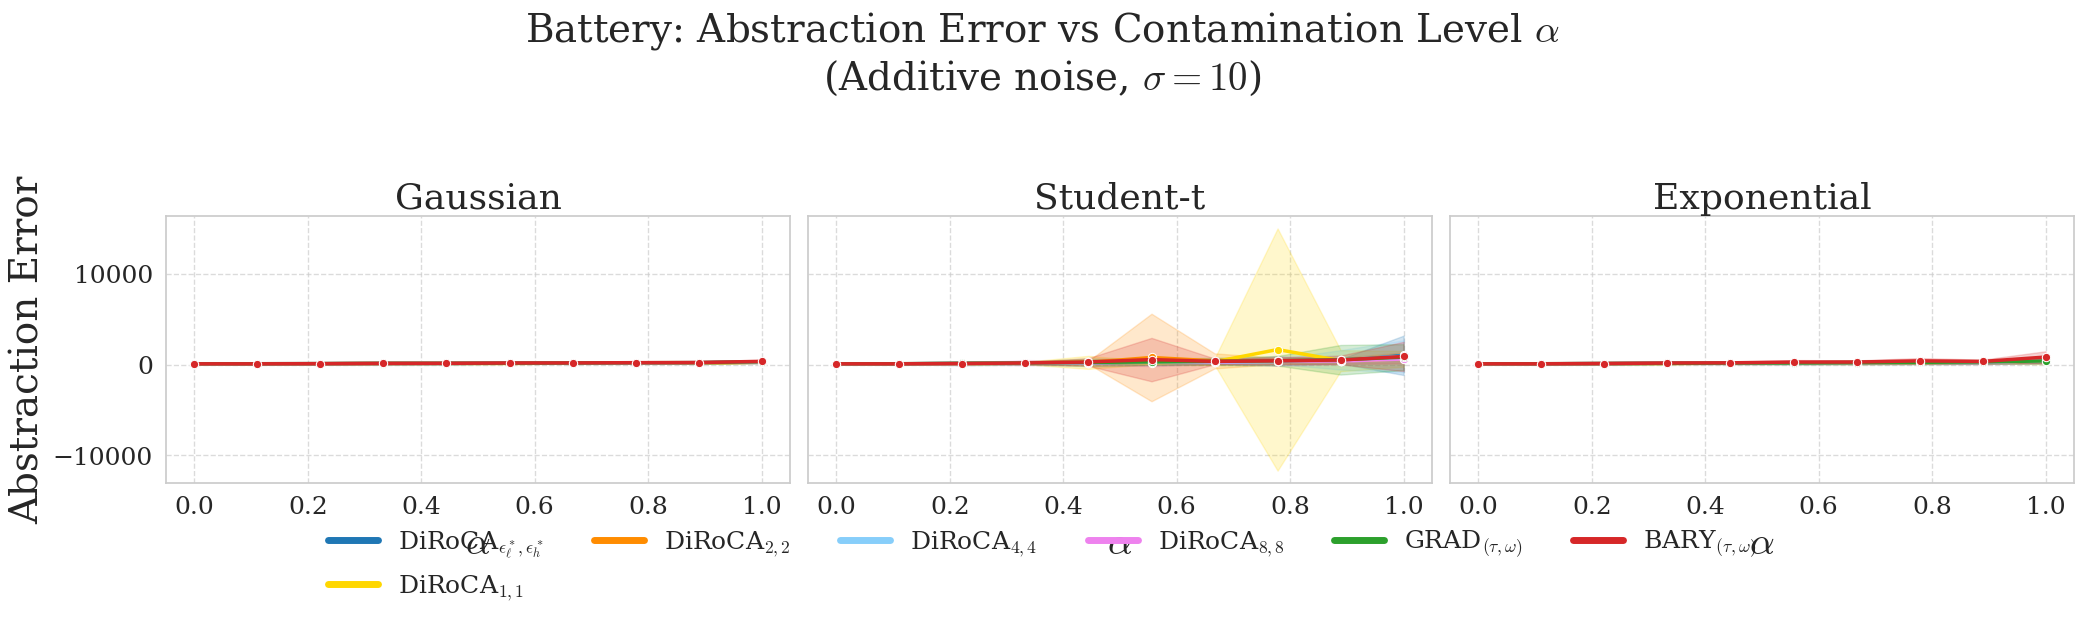

In [3]:
import glob
import os
import re

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "serif",
})

# Canonical methods we actually want to plot
methods_to_plot = [
    'DiRoCA_star',
    'DIROCA_1',
    'DIROCA_2',
    'DIROCA_4',
    'DIROCA_8',
    'GradCA',
    'BARYCA'
]

display_names = [print_label_map[m] for m in methods_to_plot]

# Colour map (same style as before)
color_map = {
    r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$': '#1f77b4',
    r'DiRoCA$_{1,1}$': 'gold',
    r'DiRoCA$_{2,2}$': 'darkorange',
    r'DiRoCA$_{4,4}$': 'lightskyblue',
    r'DiRoCA$_{8,8}$': 'violet',
    r'GRAD$_{(\tau, \omega)}$': '#2ca02c',
    r'BARY$_{(\tau, \omega)}$': '#d62728',
    r'AbsLin$_{\text{p}}$': '#9467bd',
    r'AbsLin$_{\text{n}}$': '#8c564b'
}

# For battery we fix the max noise level to 10.0 (what you used in the batch script)
NOISE_LEVEL_TO_PLOT = 10.0

def load_battery_eval(distribution: str,
                      alpha_steps: int = 10,
                      noise_steps: int = 20,
                      trials: int = 20) -> pd.DataFrame | None:
    """
    Load the most recent battery evaluation .pkl file for a given distribution.
    Files look like:
    battery_eval_additive_gaussian_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_YYYYMMDD_HHMMSS.pkl
    """
    pattern = os.path.join(
        "data", "battery", "evaluation_results",
        f"battery_eval_additive_{distribution}_alpha{alpha_steps}-*_noise{noise_steps}-*_trials{trials}_*.pkl"
    )
    files = glob.glob(pattern)
    if not files:
        print(f"No evaluation files found matching pattern:\n  {pattern}")
        return None

    files_sorted = sorted(files)
    latest = files_sorted[-1]
    print(f"Loaded evaluation file for {distribution}: {os.path.basename(latest)}")
    return pd.read_pickle(latest)

# -------------------------------------------------------
# 1 × 3 plot: one panel per contamination distribution
# -------------------------------------------------------
distributions = [
    ("gaussian",   "Gaussian"),
    ("student-t",  "Student-t"),
    ("exponential","Exponential")
]

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
fig.subplots_adjust(hspace=0.3, wspace=0.2)

present_display_names_global = set()

for ax, (dist, title_str) in zip(axes, distributions):
    df = load_battery_eval(dist, alpha_steps=10, noise_steps=20, trials=20)

    if df is None or df.empty:
        ax.set_title(title_str, fontsize=26)
        ax.set_xlabel(r'$\alpha$', fontsize=28)
        ax.set_ylabel('Abstraction Error', fontsize=28)
        ax.tick_params(axis='both', labelsize=18)
        ax.grid(True, linestyle='--', alpha=0.7)
        continue

    # Map raw method names -> canonical IDs
    df['method'] = df['method'].replace(label_map_battery)

    # Keep only methods we care about
    df = df[df['method'].isin(methods_to_plot)].copy()

    # Fix noise level slice (σ = 10.0)
    df = df[np.isclose(df['noise_scale'], NOISE_LEVEL_TO_PLOT)].copy()

    if df.empty:
        print(f"No rows left after filtering for noise_scale={NOISE_LEVEL_TO_PLOT} and methods in methods_to_plot for {dist}.")
        ax.set_title(title_str, fontsize=26)
        ax.set_xlabel(r'$\alpha$', fontsize=28)
        ax.set_ylabel('Abstraction Error', fontsize=28)
        ax.tick_params(axis='both', labelsize=18)
        ax.grid(True, linestyle='--', alpha=0.7)
        continue

    # Add display names for plotting
    df['display_name'] = df['method'].map(print_label_map)

    present_display_names_global.update(df['display_name'].unique())

    sns.lineplot(
        data=df,
        x='alpha',
        y='error',
        hue='display_name',
        hue_order=display_names,
        palette=color_map,
        marker='o',
        linewidth=2.5,
        markersize=6,
        errorbar='sd',
        ax=ax,
        legend=False
    )

    ax.set_title(title_str, fontsize=26)
    ax.set_xlabel(r'$\alpha$', fontsize=28)
    ax.set_ylabel('Abstraction Error', fontsize=28)
    ax.tick_params(axis='both', labelsize=18)
    ax.grid(True, linestyle='--', alpha=0.7)

# Global legend (only for methods that actually appear)
present_display_names_ordered = [
    lbl for lbl in display_names if lbl in present_display_names_global
]

if present_display_names_ordered:
    ordered_handles = [
        plt.Line2D([], [], linestyle='-', linewidth=5,
                   label=lbl, color=color_map.get(lbl, '#000000'))
        for lbl in present_display_names_ordered
    ]
    fig.legend(
        ordered_handles,
        present_display_names_ordered,
        loc='lower center',
        ncol=min(6, len(present_display_names_ordered)),
        fontsize=18,
        frameon=False
    )
else:
    print("No legend entries found across panels; skipping legend.")

fig.suptitle("Battery: Abstraction Error vs Contamination Level $\\alpha$\n(Additive noise, $\\sigma = 10$)", fontsize=28, y=1.03)
fig.tight_layout(rect=[0, 0.08, 1, 0.95])

os.makedirs("plots", exist_ok=True)
plt.savefig("plots/battery_abstraction_vs_alpha_1x3.png", dpi=300, bbox_inches='tight')
plt.show()


### Fix α, vary σ

In [4]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# --- 1) Label maps adapted to BATTERY naming ---

label_map_battery = {
    # DiRoCA eps configs (exactly as printed in your summaries)
    'DiRoCA (epsilon_0.558_delta_0.417)': 'DiRoCA_star',
    'DiRoCA (epsilon_0.5_delta_0.5)':     'DIROCA_0.5',  # optional, if you want it
    'DiRoCA (epsilon_1.0_delta_1.0)':     'DIROCA_1',
    'DiRoCA (epsilon_2.0_delta_2.0)':     'DIROCA_2',
    'DiRoCA (epsilon_4.0_delta_4.0)':     'DIROCA_4',
    'DiRoCA (epsilon_8.0_delta_8.0)':     'DIROCA_8',
    
    # GradCA / BaryCA (from evaluation script: method_group_key.title())
    'Gradca':                             'GradCA',
    'Baryca':                             'BARYCA',
    
    # Abs-LiNGAM (exact names from evaluation script)
    'Abs-LiNGAM (Perfect)':              'Abslin_p',
    'Abs-LiNGAM (Noisy)':                'Abslin_n'
}

# If you don't want to show the 0.5 config in plots, just don't include it in methods_to_plot below.

print_label_map  = {
    'DiRoCA_star':  r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$',
    'DIROCA_0.5':   r'DiRoCA$_{0.5,0.5}$',     # optional
    'DIROCA_1':     r'DiRoCA$_{1,1}$',
    'DIROCA_2':     r'DiRoCA$_{2,2}$',
    'DIROCA_4':     r'DiRoCA$_{4,4}$',
    'DIROCA_8':     r'DiRoCA$_{8,8}$',
    'GradCA':       r'GRAD$_{(\tau, \omega)}$',
    'BARYCA':       r'BARY$_{(\tau, \omega)}$',
    'Abslin_p':     r'AbsLin$_{\text{p}}$', 
    'Abslin_n':     r'AbsLin$_{\text{n}}$'
}

# Methods and display labels (you can drop DIROCA_0.5 if you don't want it in the main panels)
methods_to_plot = [
    'DiRoCA_star', 'DIROCA_1', 'DIROCA_2', 'DIROCA_4', 'DIROCA_8',
    'GradCA', 'BARYCA'
]
display_names = [print_label_map[m] for m in methods_to_plot]

# Color map (same structure as before)
plt.rcParams.update({
    "text.usetex": False,                 
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",             
    "mathtext.rm": "serif"
})

color_map = {
    r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$': '#1f77b4', 
    r'DiRoCA$_{1,1}$': 'gold',
    r'DiRoCA$_{2,2}$': 'darkorange',
    r'DiRoCA$_{4,4}$': 'lightskyblue',
    r'DiRoCA$_{8,8}$': 'violet',
    r'GRAD$_{(\tau, \omega)}$': '#2ca02c',                  
    r'BARY$_{(\tau, \omega)}$': '#d62728',                     
    r'AbsLin$_{\text{p}}$': '#9467bd',                       
    r'AbsLin$_{\text{n}}$': '#8c564b'                       
}

# --- 2) Loader for BATTERY evaluation results (.pkl) ---

def load_battery_results(
    distribution: str,
    shift_type: str = 'additive',
    alpha_steps: int = 10,
    alpha_min: float = 0.0,
    alpha_max: float = 1.0,
    noise_steps: int = 20,
    noise_min: float = 0.0,
    noise_max: float = 10.0,
    trials: int = 20,
    base_dir: str = "data/battery/evaluation_results"
) -> pd.DataFrame | None:
    """
    Load BATTERY empirical evaluation results for a given shift_type & distribution.
    Matches filenames like:
      battery_eval_additive_gaussian_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_YYYYMMDD_HHMMSS.pkl
    """
    pattern = (
        f"battery_eval_{shift_type}_{distribution}_"
        f"alpha{alpha_steps}-{alpha_min:.2f}-{alpha_max:.2f}_"
        f"noise{noise_steps}-{noise_min:.2f}-{noise_max:.2f}_"
        f"trials{trials}_*.pkl"
    )
    glob_pattern = os.path.join(base_dir, pattern)
    files = glob.glob(glob_pattern)

    if not files:
        print(f"No evaluation files found for pattern:\n  {glob_pattern}")
        return None
    
    # Take the latest file (by name, since timestamp is at the end)
    files.sort()
    latest = files[-1]
    print(f"Loading results from:\n  {latest}")
    df = pd.read_pickle(latest)
    return df


No evaluation files found for pattern:
  data/battery/evaluation_results/battery_eval_additive_gaussian_alpha10-0.00-1.00_noise20-0.00-5.79_trials20_*.pkl
No evaluation files found for pattern:
  data/battery/evaluation_results/battery_eval_additive_student-t_alpha10-0.00-1.00_noise20-0.00-5.79_trials20_*.pkl
No evaluation files found for pattern:
  data/battery/evaluation_results/battery_eval_additive_exponential_alpha10-0.00-1.00_noise20-0.00-5.79_trials20_*.pkl


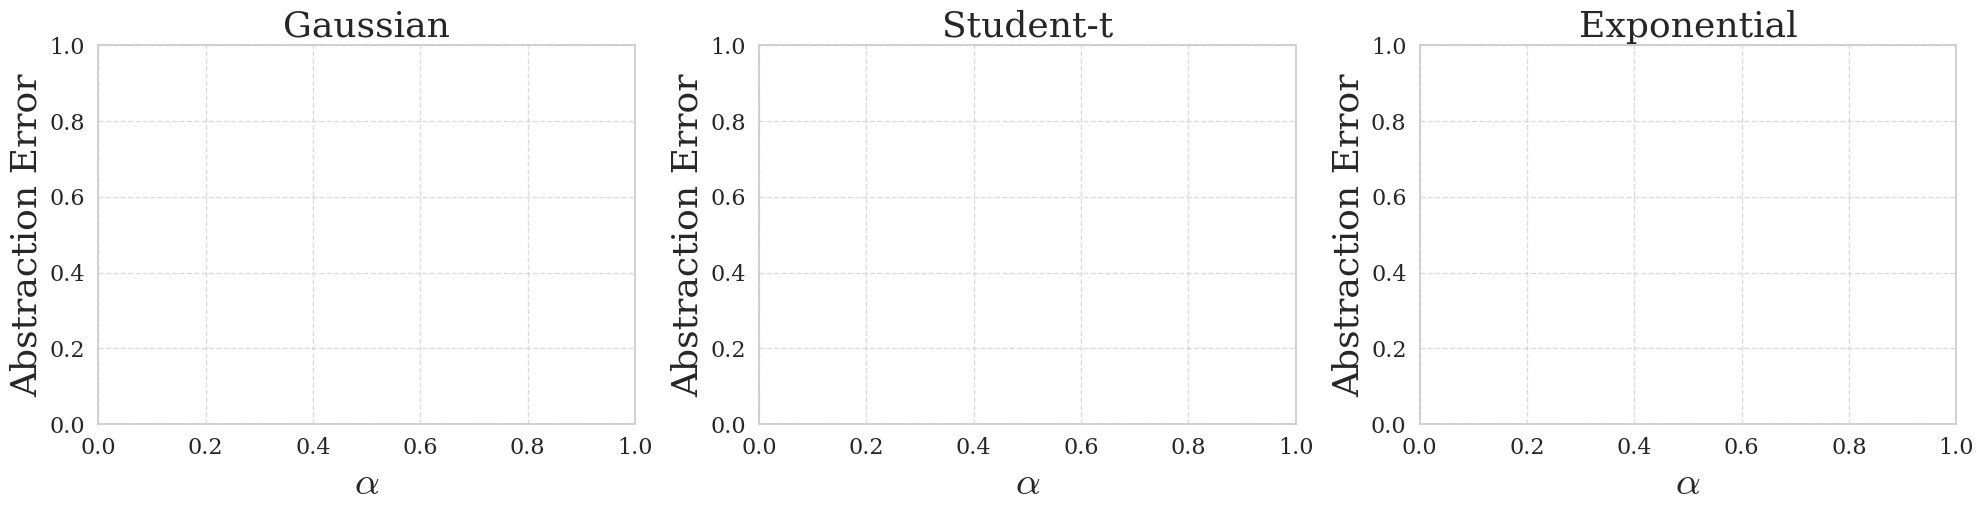

In [5]:
# Fixed noise level at which we slice alpha-curves
noise_level_to_plot = 10.0   # you can change to e.g. 5.0 if you prefer

distributions = ['gaussian', 'student-t', 'exponential']
titles = ['Gaussian', 'Student-t', 'Exponential']

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
fig.subplots_adjust(wspace=0.3)

present_display_names_global = set()

for ax, dist, title_str in zip(axes, distributions, titles):
    df = load_battery_results(
        distribution=dist,
        shift_type='additive',
        alpha_steps=10,
        alpha_min=0.0,
        alpha_max=1.0,
        noise_steps=20,
        noise_min=0.0,
        noise_max=5.789473684210526,
        trials=20
    )

    if df is None:
        ax.set_title(title_str, fontsize=26)
        ax.set_xlabel(r'$\alpha$', fontsize=28)
        ax.set_ylabel('Abstraction Error', fontsize=26)
        ax.tick_params(axis='both', labelsize=16)
        ax.grid(True, linestyle='--', alpha=0.7)
        continue

    # Map raw method names -> canonical method ids
    df['method'] = df['method'].replace(label_map_battery)

    # Filter to methods of interest and fixed noise level
    df = df[
        (np.abs(df['noise_scale'] - noise_level_to_plot) < 1e-6) &
        (df['method'].isin(methods_to_plot))
    ].copy()

    if df.empty:
        print(f"No data for distribution={dist} at noise_scale={noise_level_to_plot}")
        ax.set_title(title_str, fontsize=26)
        ax.set_xlabel(r'$\alpha$', fontsize=28)
        ax.set_ylabel('Abstraction Error', fontsize=26)
        ax.tick_params(axis='both', labelsize=16)
        ax.grid(True, linestyle='--', alpha=0.7)
        continue

    df['display_name'] = df['method'].map(print_label_map)
    present_display_names_global.update(df['display_name'].unique())

    sns.lineplot(
        data=df,
        x='alpha',
        y='error',
        hue='display_name',
        hue_order=[print_label_map[m] for m in methods_to_plot],
        palette=color_map,
        marker='o',
        linewidth=2.5,
        markersize=6,
        errorbar='sd',
        ax=ax,
        legend=False
    )

    ax.set_title(title_str, fontsize=26)
    ax.set_xlabel(r'$\alpha$', fontsize=28)
    ax.set_ylabel('Abstraction Error', fontsize=26)
    ax.tick_params(axis='both', labelsize=16)
    ax.grid(True, linestyle='--', alpha=0.7)

# Shared legend
present_display_names_ordered = [
    print_label_map[m] for m in methods_to_plot
    if print_label_map[m] in present_display_names_global
]

if present_display_names_ordered:
    ordered_handles = [
        plt.Line2D([], [], linestyle='-', linewidth=4,
                   label=lbl, color=color_map.get(lbl, '#000000'))
        for lbl in present_display_names_ordered
    ]
    fig.legend(
        ordered_handles,
        present_display_names_ordered,
        loc='lower center',
        ncol=min(6, len(present_display_names_ordered)),
        fontsize=18,
        frameon=False
    )

fig.tight_layout(rect=[0, 0.12, 1, 1])
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/battery_abstraction_vs_alpha_3x1.png", dpi=300, bbox_inches='tight')
plt.show()


In [6]:
import glob
import os
import re

# --------------------------------------------------
# 1) LABEL MAPS FOR BATTERY
# --------------------------------------------------

label_map_battery = {
    'DiRoCA (epsilon_0.558_delta_0.417)': 'DiRoCA_star',
    'DiRoCA (epsilon_0.5_delta_0.5)'    : 'DIROCA_0.5',
    'DiRoCA (epsilon_1.0_delta_1.0)'    : 'DIROCA_1',
    'DiRoCA (epsilon_2.0_delta_2.0)'    : 'DIROCA_2',
    'DiRoCA (epsilon_4.0_delta_4.0)'    : 'DIROCA_4',
    'DiRoCA (epsilon_8.0_delta_8.0)'    : 'DIROCA_8',
    'Gradca'                            : 'GradCA',
    'Baryca'                            : 'BARYCA',
    'Abs-LiNGAM (Perfect)'              : 'Abslin_p',
    'Abs-LiNGAM (Noisy)'                : 'Abslin_n',
}

print_label_map_battery = {
    'DiRoCA_star' : r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$',
    'DIROCA_0.5'  : r'DiRoCA$_{0.5,0.5}$',
    'DIROCA_1'    : r'DiRoCA$_{1,1}$',
    'DIROCA_2'    : r'DiRoCA$_{2,2}$',
    'DIROCA_4'    : r'DiRoCA$_{4,4}$',
    'DIROCA_8'    : r'DiRoCA$_{8,8}$',
    'GradCA'      : r'GRAD$_{(\tau, \omega)}$',
    'BARYCA'      : r'BARY$_{(\tau, \omega)}$',
    'Abslin_p'    : r'AbsLin$_{\text{p}}$',
    'Abslin_n'    : r'AbsLin$_{\text{n}}$'
}

methods_to_plot_battery = [
    'DiRoCA_star',
    'DIROCA_0.5',
    'DIROCA_1',
    'DIROCA_2',
    'DIROCA_4',
    'DIROCA_8',
    'GradCA',
    'BARYCA',
    'Abslin_p',
    'Abslin_n'
]

display_names_battery = [print_label_map_battery[m] for m in methods_to_plot_battery]

# Color map (same style as before, plus one color for 0.5)
color_map_battery = {
    r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$': '#1f77b4',      # star
    r'DiRoCA$_{0.5,0.5}$'                   : '#17becf',         # new
    r'DiRoCA$_{1,1}$'                       : 'gold',
    r'DiRoCA$_{2,2}$'                       : 'darkorange',
    r'DiRoCA$_{4,4}$'                       : 'lightskyblue',
    r'DiRoCA$_{8,8}$'                       : 'violet',
    r'GRAD$_{(\tau, \omega)}$'              : '#2ca02c',
    r'BARY$_{(\tau, \omega)}$'              : '#d62728',
    r'AbsLin$_{\text{p}}$'                  : '#9467bd',
    r'AbsLin$_{\text{n}}$'                  : '#8c564b',
}

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "serif"
})

# --------------------------------------------------
# 2) HELPER TO LOAD BATTERY RESULTS (FROM YOUR Pkl FILES)
# --------------------------------------------------

def load_battery_results(
    distribution='gaussian',
    shift_type='additive',
    alpha_steps=10,
    alpha_min=0.0,
    alpha_max=1.0,
    noise_steps=20,
    noise_min=0.0,
    noise_max=10.0,
    trials=20,
    verbose=True,
):
    """
    Load battery empirical evaluation results produced by run_battery_evaluation.py.
    Uses the filename pattern from run_battery_empirical_batch.sh.
    """
    pattern = (
        f"data/battery/evaluation_results/"
        f"battery_eval_{shift_type}_{distribution}_"
        f"alpha{alpha_steps}-{alpha_min:.2f}-{alpha_max:.2f}_"
        f"noise{noise_steps}-{noise_min:.2f}-{noise_max:.2f}_"
        f"trials{trials}_*.pkl"
    )
    files = glob.glob(pattern)
    if not files:
        if verbose:
            print(f"No files match pattern:\n  {pattern}")
        return None
    
    files.sort()
    path = files[-1]  # take the latest
    if verbose:
        print(f"Loading results from:\n  {path}")
    return pd.read_pickle(path)


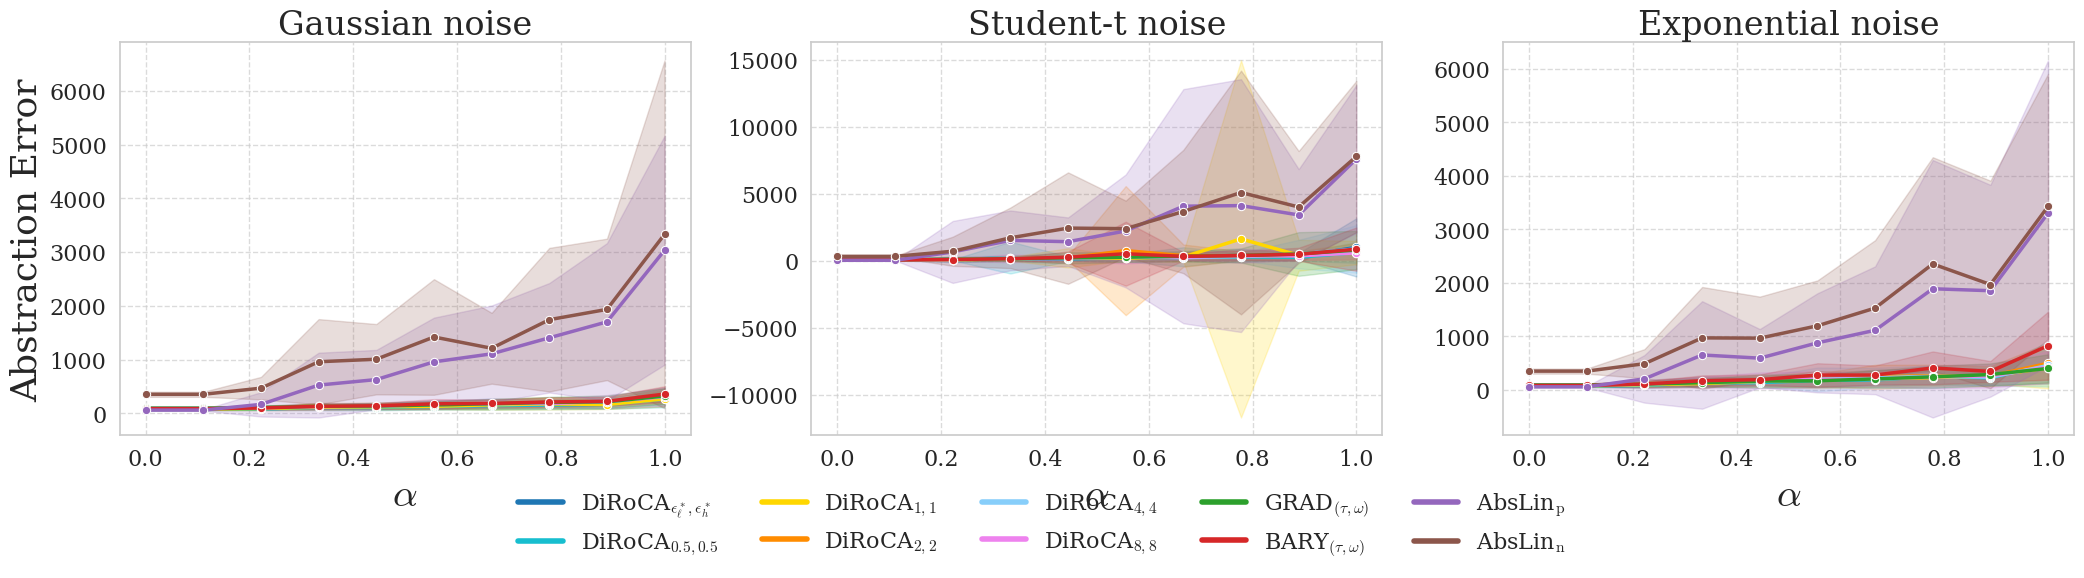

In [7]:
# Fix noise level at the maximum used in evaluation (10.0)
noise_level_to_plot = 10.0

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=False)
fig.subplots_adjust(wspace=0.3)

panels = [
    (0, 'gaussian',  "Gaussian noise"),
    (1, 'student-t', "Student-t noise"),
    (2, 'exponential', "Exponential noise"),
]

present_display_names_global = set()

for idx, distribution, title_str in panels:
    ax = axes[idx]
    
    df = load_battery_results(
        distribution=distribution,
        shift_type='additive',
        alpha_steps=10,
        alpha_min=0.0,
        alpha_max=1.0,
        noise_steps=20,
        noise_min=0.0,
        noise_max=10.0,
        trials=20,
        verbose=False
    )
    
    if df is None or df.empty:
        print(f"No data found for distribution={distribution}")
        ax.set_title(title_str, fontsize=24)
        ax.set_xlabel(r'$\alpha$', fontsize=28)
        ax.set_ylabel('Abstraction Error' if idx == 0 else '', fontsize=26)
        ax.tick_params(axis='both', labelsize=16)
        ax.grid(True, linestyle='--', alpha=0.7)
        continue
    
    # Map method labels to canonical short names
    df['method'] = df['method'].replace(label_map_battery)
    
    # Keep only methods we care about
    df = df[df['method'].isin(methods_to_plot_battery)].copy()
    
    # Fix noise level
    df = df[np.isclose(df['noise_scale'], noise_level_to_plot)].copy()
    
    if df.empty:
        print(f"No data for distribution={distribution} at noise_scale={noise_level_to_plot}")
        ax.set_title(title_str, fontsize=24)
        ax.set_xlabel(r'$\alpha$', fontsize=28)
        ax.set_ylabel('Abstraction Error' if idx == 0 else '', fontsize=26)
        ax.tick_params(axis='both', labelsize=16)
        ax.grid(True, linestyle='--', alpha=0.7)
        continue
    
    # Map to pretty display names
    df['display_name'] = df['method'].map(print_label_map_battery)
    
    sns.lineplot(
        data=df,
        x='alpha',
        y='error',
        hue='display_name',
        hue_order=[print_label_map_battery[m] for m in methods_to_plot_battery],
        palette=color_map_battery,
        marker='o',
        linewidth=2.5,
        markersize=6,
        errorbar='sd',
        ax=ax,
        legend=False
    )
    
    present_display_names_global.update(df['display_name'].unique())
    
    ax.set_title(title_str, fontsize=24)
    ax.set_xlabel(r'$\alpha$', fontsize=28)
    ax.set_ylabel('Abstraction Error' if idx == 0 else '', fontsize=26)
    ax.tick_params(axis='both', labelsize=16)
    ax.grid(True, linestyle='--', alpha=0.7)

# Global legend
present_display_names_ordered = [
    print_label_map_battery[m]
    for m in methods_to_plot_battery
    if print_label_map_battery[m] in present_display_names_global
]

if present_display_names_ordered:
    ordered_handles = [
        plt.Line2D([], [], linestyle='-', linewidth=4,
                   label=lbl, color=color_map_battery.get(lbl, '#000000'))
        for lbl in present_display_names_ordered
    ]
    fig.legend(
        ordered_handles,
        present_display_names_ordered,
        loc='lower center',
        ncol=min(5, len(present_display_names_ordered)),
        fontsize=16,
        frameon=False
    )
else:
    print("No legend entries found; skipping legend.")

fig.tight_layout(rect=[0, 0.08, 1, 0.98])
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/battery_abstraction_vs_alpha_3noise.png", dpi=300, bbox_inches='tight')
plt.show()


In [8]:
distribution = 'gaussian'  # or 'student-t', 'exponential'

results_df = load_battery_results(
    distribution=distribution,
    shift_type='additive',
    alpha_steps=10,
    alpha_min=0.0,
    alpha_max=1.0,
    noise_steps=20,
    noise_min=0.0,
    noise_max=10.0,
    trials=20,
    verbose=False
)

if results_df is None or results_df.empty:
    print("No evaluation results to analyze.")
else:
    # Map method labels
    results_df['method'] = results_df['method'].replace(label_map_battery)
    
    df_clean = results_df[np.isclose(results_df['alpha'], 0.0)]
    summary_stats = df_clean.groupby(['method'])['error'].agg(['mean', 'std', 'count'])
    summary_stats['sem'] = summary_stats['std']  # or / sqrt(count) if you prefer
    
    print(f"--- Final Summary on clean data (α = 0.0), distribution = {distribution} ---\n")
    print("=" * 70)
    print(f"{'Method/Run':<45} | {'Mean ± Std'}")
    print("=" * 70)
    
    # Sort by mean error (ascending)
    for method_name, row in summary_stats.sort_values('mean').iterrows():
        mean_val = row['mean']
        sem_val  = row['sem']
        print(f"{method_name:<45} | {mean_val:>7.4f} ± {sem_val:.4f}")
    
    print("=" * 70)


--- Final Summary on clean data (α = 0.0), distribution = gaussian ---

Method/Run                                    | Mean ± Std
Abslin_p                                      | 58.8510 ± 11.2187
DIROCA_0.5                                    | 73.1040 ± 13.0533
DIROCA_1                                      | 77.7995 ± 19.8342
DiRoCA_star                                   | 83.9622 ± 28.4997
BARYCA                                        | 84.0323 ± 13.9935
DIROCA_4                                      | 91.7588 ± 26.9582
DIROCA_8                                      | 91.7588 ± 26.9582
DIROCA_2                                      | 92.5506 ± 25.9857
GradCA                                        | 93.5285 ± 26.3011
Abslin_n                                      | 352.8224 ± 46.8472


In [9]:
label_map_battery = {
    'DiRoCA (epsilon_0.558_delta_0.417)': 'DiRoCA_star',
    'DiRoCA (epsilon_0.5_delta_0.5)'    : 'DIROCA_0.5',
    'DiRoCA (epsilon_1.0_delta_1.0)'    : 'DIROCA_1',
    'DiRoCA (epsilon_2.0_delta_2.0)'    : 'DIROCA_2',
    'DiRoCA (epsilon_4.0_delta_4.0)'    : 'DIROCA_4',
    'DiRoCA (epsilon_8.0_delta_8.0)'    : 'DIROCA_8',
    'Gradca'                             : 'GradCA',
    'Baryca'                             : 'BARYCA',
    'Abs-LiNGAM (Perfect)'              : 'Abslin_p',
    'Abs-LiNGAM (Noisy)'                : 'Abslin_n',
}

print_label_map  = {
    'DiRoCA_star':  r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$',
    'DIROCA_0.5':   r'DiRoCA$_{0.5,0.5}$',
    'DIROCA_1':     r'DiRoCA$_{1,1}$',
    'DIROCA_2':     r'DiRoCA$_{2,2}$',
    'DIROCA_4':     r'DiRoCA$_{4,4}$',
    'DIROCA_8':     r'DiRoCA$_{8,8}$',
    'GradCA':       r'GRAD$_{(\tau, \omega)}$',
    'BARYCA':       r'BARY$_{(\tau, \omega)}$',
    'Abslin_p':     r'AbsLin$_{\text{p}}$', 
    'Abslin_n':     r'AbsLin$_{\text{n}}$'
}

methods_to_plot = [
    'DiRoCA_star', 'DIROCA_0.5', 'DIROCA_1', 'DIROCA_2', 'DIROCA_4', 'DIROCA_8',
    'GradCA', 'BARYCA', 'Abslin_p', 'Abslin_n'
]
display_names = [print_label_map[m] for m in methods_to_plot]


In [10]:
import glob
import os
import re
import pandas as pd

def load_battery_results(
    distribution='gaussian',
    shift_type='additive',
    alpha_steps=10,
    alpha_min=0.0,
    alpha_max=1.0,
    noise_steps=20,
    noise_min=0.0,
    noise_max=10.0,
    trials=20,
):
    """
    Load battery evaluation results written by run_battery_empirical_evaluation.py.
    Returns a concatenated DataFrame over all matching PKL files.
    """
    base_dir = "data/battery/evaluation_results"
    pattern = (
        f"battery_eval_{shift_type}_{distribution}_"
        f"alpha{alpha_steps}-{alpha_min:.2f}-{alpha_max:.2f}_"
        f"noise{noise_steps}-{noise_min:.2f}-{noise_max:.2f}_"
        f"trials{trials}_*.pkl"
    )
    full_pattern = os.path.join(base_dir, pattern)
    files = sorted(glob.glob(full_pattern))
    
    if not files:
        print(f"No evaluation files found for pattern:\n  {full_pattern}")
        return None
    
    dfs = []
    for f in files:
        df = pd.read_pickle(f)
        df['source_file'] = os.path.basename(f)
        dfs.append(df)
    out = pd.concat(dfs, ignore_index=True)
    print(f"Loaded {len(files)} file(s), total {len(out)} rows.")
    return out


In [11]:
experiment      = 'battery'
evaluation_type = 'gaussian'  # just a label now

# This matches exactly what your batch script used
final_results_df = load_battery_results(
    distribution='gaussian',
    shift_type='additive',
    alpha_steps=10,
    alpha_min=0.0,
    alpha_max=1.0,
    noise_steps=20,
    noise_min=0.0,
    noise_max=10.0,   # battery used noise_max=10
    trials=20,
)

# Map raw method names -> canonical names
final_results_df['method'] = final_results_df['method'].replace(label_map_battery)


Loaded 2 file(s), total 400000 rows.


In [12]:
df_clean = final_results_df[
    (final_results_df['alpha'] == 0.0) &
    (final_results_df['noise_scale'] == 0.0)
]

summary_stats = df_clean.groupby(['method'])['error'].agg(['mean', 'std', 'count'])
summary_stats['sem'] = summary_stats['std']  # / np.sqrt(summary_stats['count']) if you want SEM

print("--- Final Summary on clean data (alpha=0, sigma=0) ---\n")
print("="*65)
print(f"{'Method/Run':<45} | {'Mean ± Std'}")
print("="*65)

for method_name, row in summary_stats.iterrows():
    mean_val = row['mean']
    std_val  = row['std']
    print(f"{method_name:<45} | {mean_val:>7.4f} ± {std_val:.4f}")
print("="*65)


--- Final Summary on clean data (alpha=0, sigma=0) ---

Method/Run                                    | Mean ± Std
Abslin_n                                      | 352.8224 ± 46.9530
Abslin_p                                      | 58.8510 ± 11.2440
BARYCA                                        | 140.0400 ± 65.5855
DIROCA_0.5                                    | 73.1040 ± 13.0827
DIROCA_1                                      | 77.7995 ± 19.8790
DIROCA_2                                      | 92.5506 ± 26.0444
DIROCA_4                                      | 91.7588 ± 27.0190
DIROCA_8                                      | 91.7588 ± 27.0190
DiRoCA_star                                   | 83.9622 ± 28.5641
GradCA                                        | 93.5285 ± 26.3605


In [13]:
alpha_point        = 1.0
noise_level_point  = 5.789473684210526  # battery eval used noise_max=10

df_point = final_results_df[
    (final_results_df['alpha'] == alpha_point) &
    (final_results_df['noise_scale'] == noise_level_point)
]

summary_stats = df_point.groupby(['method'])['error'].agg(['mean', 'std', 'count'])
summary_stats['sem'] = summary_stats['std'] / np.sqrt(summary_stats['count'])

print(f"\n--- Summary at alpha={alpha_point}, sigma={noise_level_point} ---\n")
print("="*65)
print(f"{'Method/Run':<45} | {'Mean ± Std'}")
print("="*65)

for method_name, row in summary_stats.iterrows():
    mean_val = row['mean']
    std_val  = row['std']
    print(f"{method_name:<45} | {mean_val:>7.4f} ± {std_val:.4f}")
print("="*65)



--- Summary at alpha=1.0, sigma=5.789473684210526 ---

Method/Run                                    | Mean ± Std
Abslin_n                                      | 1330.7504 ± 738.1887
Abslin_p                                      | 1107.6033 ± 830.0616
BARYCA                                        | 189.1510 ± 65.2690
DIROCA_0.5                                    | 137.4219 ± 60.4755
DIROCA_1                                      | 140.1386 ± 69.2424
DIROCA_2                                      | 175.8622 ± 74.8310
DIROCA_4                                      | 160.7138 ± 69.0256
DIROCA_8                                      | 166.8882 ± 74.2793
DiRoCA_star                                   | 159.2733 ± 86.4019
GradCA                                        | 170.4052 ± 68.6294


In [14]:
# Cell 1 — Imports + small helpers (battery evaluation notebook)

import os, re, glob, random
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# --- Paths ---
BATTERY_DIR = Path("data/battery")
EVAL_DIR = BATTERY_DIR / "evaluation_results"

# --- Result loader for battery ---
def load_battery_results(
    distribution="gaussian",
    shift_type="additive",
    alpha_steps=10, alpha_min=0.0, alpha_max=1.0,
    noise_steps=20, noise_min=0.0, noise_max=10.0,
    trials=20,
):
    """
    Loads battery empirical eval results produced by run_battery_evaluation.py.
    Returns a concatenated DataFrame (or None if not found).
    """
    pattern = (
        f"battery_eval_{shift_type}_{distribution}"
        f"_alpha{alpha_steps}-{alpha_min:.2f}-{alpha_max:.2f}"
        f"_noise{noise_steps}-{noise_min:.2f}-{noise_max:.2f}"
        f"_trials{trials}_*.pkl"
    )
    files = sorted(glob.glob(str(EVAL_DIR / pattern)))
    if len(files) == 0:
        print(f"❌ No files match: {pattern}")
        return None

    dfs = []
    for fp in files:
        df = joblib.load(fp)
        # allow older runs saved as dict/list
        if isinstance(df, list):
            df = pd.DataFrame(df)
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)
    return out

def available_sigmas(df: pd.DataFrame):
    """Quick helper to see sigma/noise_scale grid in a loaded DF."""
    if df is None or df.empty:
        return np.array([])
    return np.sort(df["noise_scale"].unique())


In [15]:
# Cell 2 — Method name maps for battery + display labels

# What appears in the battery eval pkl "method" column:
label_map_battery = {
    # DiRoCA sweeps (as saved by optimization_modular)
    'DiRoCA (epsilon_0.558_delta_0.417)': 'DiRoCA_star',
    'DiRoCA (epsilon_0.5_delta_0.5)':     'DiRoCA_0p5',
    'DiRoCA (epsilon_1.0_delta_1.0)':     'DiRoCA_1',
    'DiRoCA (epsilon_2.0_delta_2.0)':     'DiRoCA_2',
    'DiRoCA (epsilon_4.0_delta_4.0)':     'DiRoCA_4',
    'DiRoCA (epsilon_8.0_delta_8.0)':     'DiRoCA_8',

    # Baselines
    'Gradca':                'GradCA',
    'Baryca':                'BARYCA',
    'Abs-LiNGAM (Perfect)':  'Abslin_p',
    'Abs-LiNGAM (Noisy)':    'Abslin_n',
}

print_label_map = {
    'DiRoCA_star': r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$',
    'DiRoCA_0p5':  r'DiRoCA$_{0.5,0.5}$',
    'DiRoCA_1':    r'DiRoCA$_{1,1}$',
    'DiRoCA_2':    r'DiRoCA$_{2,2}$',
    'DiRoCA_4':    r'DiRoCA$_{4,4}$',
    'DiRoCA_8':    r'DiRoCA$_{8,8}$',
    'GradCA':      r'GRAD$_{(\tau,\omega)}$',
    'BARYCA':      r'BARY$_{(\tau,\omega)}$',
    'Abslin_p':    r'AbsLin$_{\text{p}}$',
    'Abslin_n':    r'AbsLin$_{\text{n}}$',
}

methods_to_plot = [
    'DiRoCA_star','DiRoCA_0p5','DiRoCA_1','DiRoCA_2','DiRoCA_4','DiRoCA_8',
     'GradCA','BARYCA'
] 
# ,'Abslin_p','Abslin_n'
display_names = [print_label_map[m] for m in methods_to_plot]

# Consistent colors (reuse your old palette if you want)
palette = sns.color_palette("colorblind", n_colors=len(display_names))
color_map = dict(zip(display_names, palette))


Using fixed σ ≈ 5.263157894736842 (closest to target 5.0)


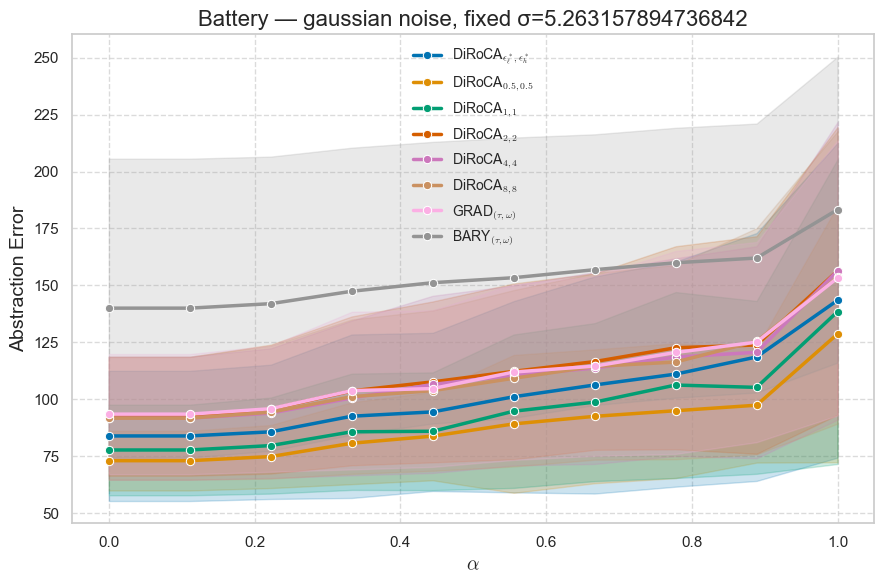

In [16]:
# --- Fix sigma, vary alpha (Battery) ---

experiment = "battery"
distribution = "gaussian"     # change to "student-t" or "exponential" as needed
shift_type = "additive"

df = load_battery_results(distribution=distribution, shift_type=shift_type)

# Replace raw method names -> compact names
df["method"] = df["method"].replace(label_map_battery)

# Choose a sigma to fix. For battery runs noise_max=10, so default target is 10.
target_sigma = 5.0
sigmas = available_sigmas(df)
sigma_fixed = sigmas[np.argmin(np.abs(sigmas - target_sigma))]
print(f"Using fixed σ ≈ {sigma_fixed} (closest to target {target_sigma})")

df_plot = df[
    (np.isclose(df["noise_scale"], sigma_fixed)) &
    (df["method"].isin(methods_to_plot))
].copy()

df_plot["display_name"] = df_plot["method"].map(print_label_map)

plt.figure(figsize=(9,6))
sns.lineplot(
    data=df_plot,
    x="alpha",
    y="error",
    hue="display_name",
    hue_order=display_names,
    palette=color_map,
    marker="o",
    linewidth=2.5,
    markersize=6,
    errorbar="sd",
)
plt.title(f"Battery — {distribution} noise, fixed σ={sigma_fixed}", fontsize=16)
plt.xlabel(r"$\alpha$", fontsize=14)
plt.ylabel("Abstraction Error", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(fontsize=10, frameon=False)
plt.tight_layout()
plt.show()


Plotting σ up to 10.0 (closest ≤ 5.0)


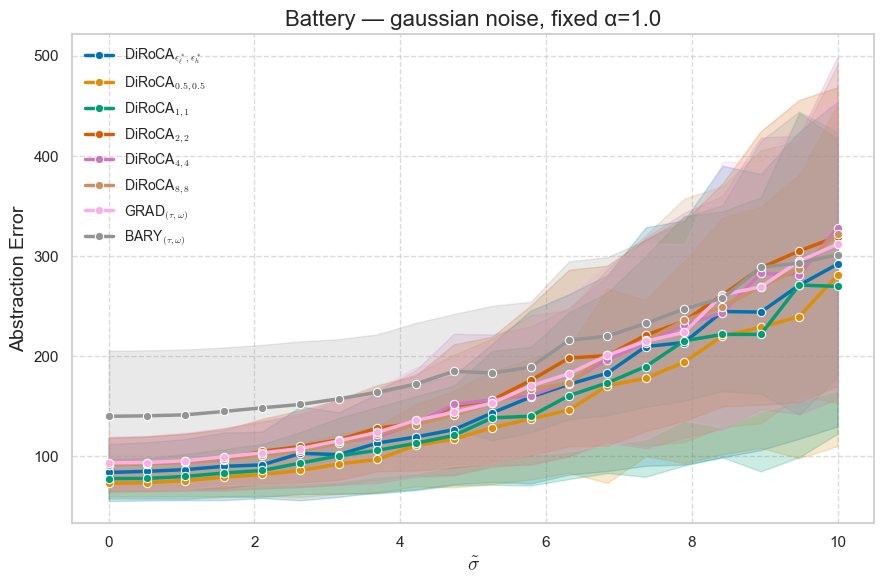

In [18]:
# --- Fix alpha, vary sigma up to 5.0 (or closest available) ---

experiment = "battery"
distribution = "gaussian"
shift_type = "additive"

df = load_battery_results(distribution=distribution, shift_type=shift_type)

df["method"] = df["method"].replace(label_map_battery)

fixed_alpha = 1.0   # same convention as old notebooks; change if you want
sigmas = available_sigmas(df)

# We want sigma to go up to 5.0 or closest we have.
target_max_sigma = 10.0
max_sigma_available = sigmas[sigmas <= target_max_sigma].max() if np.any(sigmas <= target_max_sigma) else sigmas.min()
print(f"Plotting σ up to {max_sigma_available} (closest ≤ 5.0)")

df_plot = df[
    (np.isclose(df["alpha"], fixed_alpha)) &
    (df["noise_scale"] <= max_sigma_available) &
    (df["method"].isin(methods_to_plot))
].copy()

df_plot["display_name"] = df_plot["method"].map(print_label_map)

plt.figure(figsize=(9,6))
sns.lineplot(
    data=df_plot,
    x="noise_scale",
    y="error",
    hue="display_name",
    hue_order=display_names,
    palette=color_map,
    marker="o",
    linewidth=2.5,
    markersize=6,
    errorbar="sd",
)
plt.title(f"Battery — {distribution} noise, fixed α={fixed_alpha}", fontsize=16)
plt.xlabel(r"$\tilde{\sigma}$", fontsize=14)
plt.ylabel("Abstraction Error", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(fontsize=10, frameon=False)
plt.tight_layout()
plt.show()


In [19]:
# ==== Imports ====
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
seed = 42
np.random.seed(seed)

# ==== Helper: load latest battery eval file for a given distribution ====
def load_latest_battery_eval(distribution="gaussian", shift_type="additive",
                             eval_dir="data/battery/evaluation_results"):
    pattern = os.path.join(eval_dir, f"battery_eval_{shift_type}_{distribution}_*.pkl")
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No eval files found with pattern: {pattern}")
    latest = files[-1]
    print(f"Loading: {latest}")
    df = pd.read_pickle(latest)
    return df

# ==== Helper: get closest available value ====
def closest_value(values, target):
    values = np.array(sorted(np.unique(values)))
    idx = int(np.argmin(np.abs(values - target)))
    return float(values[idx]), values


In [20]:
# ==== Method label maps (battery) ====
label_map_battery = {
    # DiRoCA runs (match your saved names)
    'DiRoCA (epsilon_0.558_delta_0.417)': 'DiRoCA_star',
    'DiRoCA (epsilon_0.5_delta_0.5)':     'DiRoCA_0.5',
    'DiRoCA (epsilon_1.0_delta_1.0)':     'DiRoCA_1',
    'DiRoCA (epsilon_2.0_delta_2.0)':     'DiRoCA_2',
    'DiRoCA (epsilon_4.0_delta_4.0)':     'DiRoCA_4',
    'DiRoCA (epsilon_8.0_delta_8.0)':     'DiRoCA_8',
    
    # baselines
    'Gradca':                'GradCA',
    'Baryca':                'BARYCA',
    'Abs-LiNGAM (Perfect)':  'Abslin_p',
    'Abs-LiNGAM (Noisy)':    'Abslin_n',
}

print_label_map = {
    'DiRoCA_star': r'DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$',
    'DiRoCA_0.5':  r'DiRoCA$_{0.5,0.5}$',
    'DiRoCA_1':    r'DiRoCA$_{1,1}$',
    'DiRoCA_2':    r'DiRoCA$_{2,2}$',
    'DiRoCA_4':    r'DiRoCA$_{4,4}$',
    'DiRoCA_8':    r'DiRoCA$_{8,8}$',
    'GradCA':      r'GRAD$_{(\tau,\omega)}$',
    'BARYCA':      r'BARY$_{(\tau,\omega)}$',
    'Abslin_p':    r'AbsLin$_{\text{p}}$',
    'Abslin_n':    r'AbsLin$_{\text{n}}$',
}

methods_to_plot = list(print_label_map.keys())
display_names = [print_label_map[m] for m in methods_to_plot]

# consistent palette
palette = sns.color_palette("colorblind", n_colors=len(display_names))
color_map = dict(zip(display_names, palette))


Loading: data/battery/evaluation_results/battery_eval_additive_gaussian_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_20251121_150415.pkl
Available sigma values: [0.         0.52631579 1.05263158 1.57894737 2.10526316 2.63157895
 3.15789474 3.68421053 4.21052632 4.73684211] ... [ 8.94736842  9.47368421 10.        ]
Chosen sigma_closest = 5.263 (target 5.0)


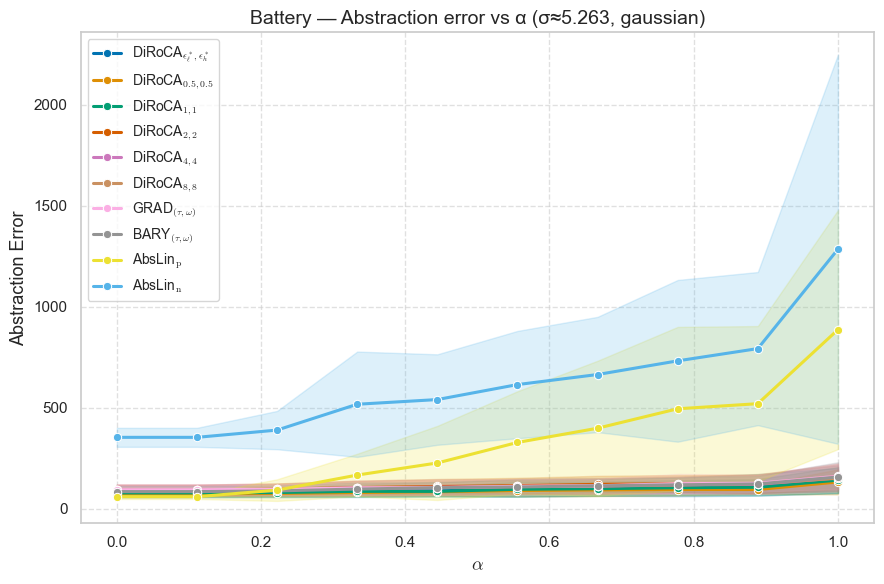

In [21]:
# ==== Load results (choose distribution) ====
distribution = "gaussian"   # "student-t" or "exponential" if you want another file
df = load_latest_battery_eval(distribution=distribution)

# map -> short internal names, then to pretty names
df["method_raw"] = df["method"]
df["method"] = df["method"].replace(label_map_battery)

# keep only methods we know how to display
df = df[df["method"].isin(methods_to_plot)].copy()
df["display_name"] = df["method"].map(print_label_map)

# pick sigma closest to 5.0
sigma_target = 5.0
sigma_closest, sigma_values = closest_value(df["noise_scale"], sigma_target)
print("Available sigma values:", sigma_values[:10], "...", sigma_values[-3:])
print(f"Chosen sigma_closest = {sigma_closest:.3f} (target {sigma_target})")

df_sig = df[np.isclose(df["noise_scale"], sigma_closest)].copy()

plt.figure(figsize=(9,6))
sns.lineplot(
    data=df_sig,
    x="alpha", y="error",
    hue="display_name",
    hue_order=display_names,
    palette=color_map,
    marker="o", linewidth=2.2, errorbar="sd"
)
plt.title(f"Battery — Abstraction error vs α (σ≈{sigma_closest:.3f}, {distribution})", fontsize=14)
plt.xlabel(r"$\alpha$", fontsize=13)
plt.ylabel("Abstraction Error", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="", fontsize=10)
plt.tight_layout()
plt.show()


Loading: data/battery/evaluation_results/battery_eval_additive_gaussian_alpha10-0.00-1.00_noise20-0.00-10.00_trials20_20251120_170034.pkl
Available sigma values: [0.         0.52631579 1.05263158 1.57894737 2.10526316 2.63157895
 3.15789474 3.68421053 4.21052632 4.73684211] ... [ 8.94736842  9.47368421 10.        ]
Chosen sigma_closest = 5.263 (target 5.0)


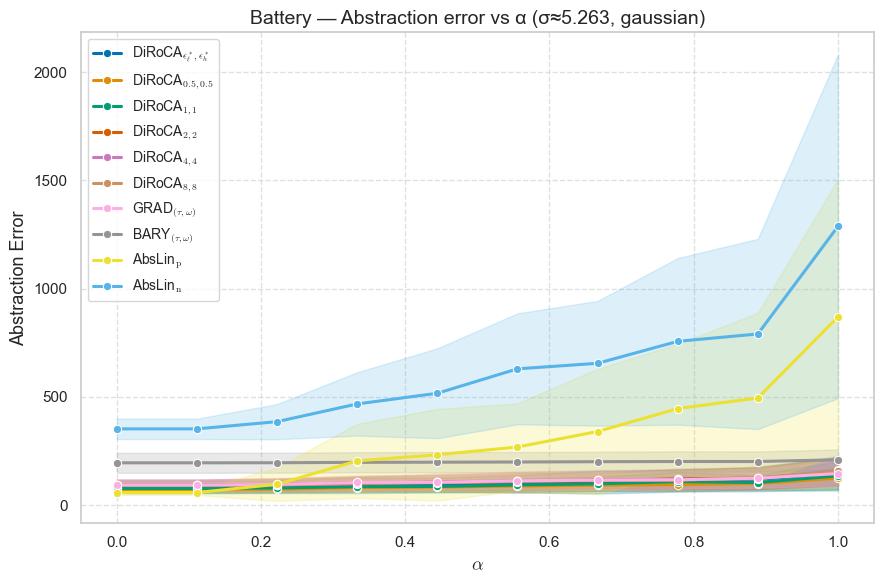

In [61]:
# ==== Load results (choose distribution) ====
distribution = "gaussian"   # "student-t" or "exponential" if you want another file
df = load_latest_battery_eval(distribution=distribution)

# map -> short internal names, then to pretty names
df["method_raw"] = df["method"]
df["method"] = df["method"].replace(label_map_battery)

# keep only methods we know how to display
df = df[df["method"].isin(methods_to_plot)].copy()
df["display_name"] = df["method"].map(print_label_map)

# pick sigma closest to 5.0
sigma_target = 5.0
sigma_closest, sigma_values = closest_value(df["noise_scale"], sigma_target)
print("Available sigma values:", sigma_values[:10], "...", sigma_values[-3:])
print(f"Chosen sigma_closest = {sigma_closest:.3f} (target {sigma_target})")

df_sig = df[np.isclose(df["noise_scale"], sigma_closest)].copy()

plt.figure(figsize=(9,6))
sns.lineplot(
    data=df_sig,
    x="alpha", y="error",
    hue="display_name",
    hue_order=display_names,
    palette=color_map,
    marker="o", linewidth=2.2, errorbar="sd"
)
plt.title(f"Battery — Abstraction error vs α (σ≈{sigma_closest:.3f}, {distribution})", fontsize=14)
plt.xlabel(r"$\alpha$", fontsize=13)
plt.ylabel("Abstraction Error", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="", fontsize=10)
plt.tight_layout()
plt.show()


Plotting sigma up to 4.737


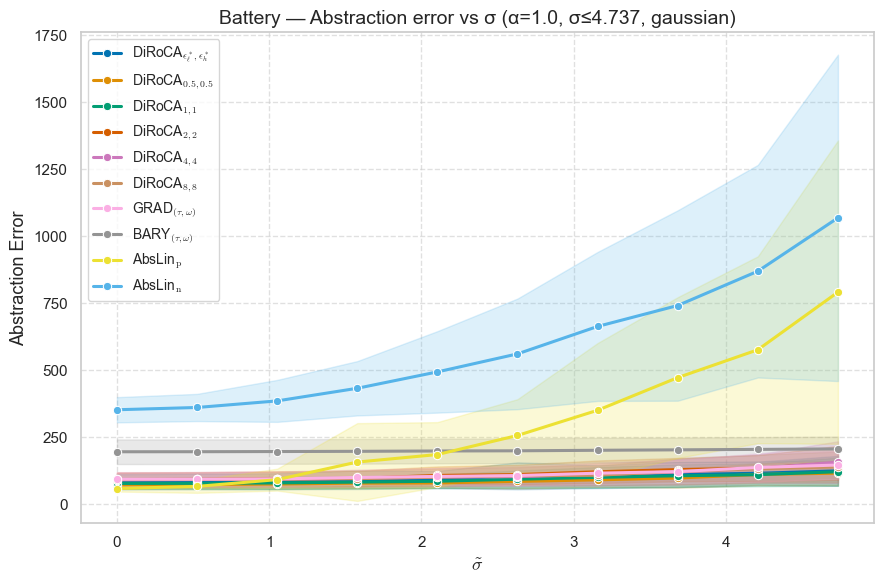

In [62]:
# ==== Fix alpha, vary sigma ====
alpha_target = 1.0

# choose max sigma <= 5.0 if possible; otherwise closest overall
sigmas_sorted = np.array(sorted(np.unique(df["noise_scale"])))
sigmas_leq = sigmas_sorted[sigmas_sorted <= 5.0 + 1e-9]
if len(sigmas_leq) > 0:
    sigma_max_to_plot = float(sigmas_leq[-1])
else:
    sigma_max_to_plot, _ = closest_value(sigmas_sorted, 5.0)

print(f"Plotting sigma up to {sigma_max_to_plot:.3f}")

df_alpha = df[np.isclose(df["alpha"], alpha_target)].copy()
df_alpha = df_alpha[df_alpha["noise_scale"] <= sigma_max_to_plot + 1e-9]

plt.figure(figsize=(9,6))
sns.lineplot(
    data=df_alpha,
    x="noise_scale", y="error",
    hue="display_name",
    hue_order=display_names,
    palette=color_map,
    marker="o", linewidth=2.2, errorbar="sd"
)
plt.title(f"Battery — Abstraction error vs σ (α={alpha_target}, σ≤{sigma_max_to_plot:.3f}, {distribution})", fontsize=14)
plt.xlabel(r"$\tilde{\sigma}$", fontsize=13)
plt.ylabel("Abstraction Error", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="", fontsize=10)
plt.tight_layout()
plt.show()


In [22]:
# ==== Summary tables at alpha=0 and alpha=1 for sigma≈5.0 ====
sigma_target = 5.0
sigma_closest, sigma_values = closest_value(df["noise_scale"], sigma_target)

def summary_at(alpha_val):
    sub = df[
        np.isclose(df["alpha"], alpha_val) &
        np.isclose(df["noise_scale"], sigma_closest)
    ].copy()
    if sub.empty:
        return pd.DataFrame()
    out = (sub.groupby("display_name")["error"]
              .agg(["mean","std","count"])
              .sort_values("mean"))
    return out

summary_alpha0 = summary_at(0.0)
summary_alpha1 = summary_at(1.0)

print(f"\n=== Battery summary at α = 0.0 (clean), σ ≈ {sigma_closest:.3f} ===")
display(summary_alpha0)

print(f"\n=== Battery summary at α = 1.0 (fully contaminated), σ ≈ {sigma_closest:.3f} ===")
display(summary_alpha1)



=== Battery summary at α = 0.0 (clean), σ ≈ 5.263 ===


,mean,std,count
display_name,,,
AbsLin$_{\text{p}}$,58.851008,11.272351,100
"DiRoCA$_{0.5,0.5}$",73.104021,13.115735,100
"DiRoCA$_{1,1}$",77.799464,19.929163,100
"DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$",83.962193,28.636135,100
"BARY$_{(\tau,\omega)}$",84.032278,14.060462,100
"DiRoCA$_{4,4}$",91.758845,27.087187,100
"DiRoCA$_{8,8}$",91.758845,27.087187,100
"DiRoCA$_{2,2}$",92.550615,26.110092,100
"GRAD$_{(\tau,\omega)}$",93.528501,26.426985,100



=== Battery summary at α = 1.0 (fully contaminated), σ ≈ 5.263 ===


,mean,std,count
display_name,,,
"DiRoCA$_{0.5,0.5}$",131.872126,62.215931,100
"DiRoCA$_{\epsilon_\ell^*, \epsilon_h^*}$",139.036178,62.285566,100
"DiRoCA$_{1,1}$",141.036503,65.350650,100
"DiRoCA$_{8,8}$",150.067234,64.257153,100
"DiRoCA$_{4,4}$",152.079382,63.613025,100
"BARY$_{(\tau,\omega)}$",156.475383,73.110510,100
"DiRoCA$_{2,2}$",158.771240,63.249777,100
"GRAD$_{(\tau,\omega)}$",160.201961,63.991745,100
AbsLin$_{\text{p}}$,886.399673,591.972814,100
